# Import Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
pip install --upgrade jupyter_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 3.6 MB/s eta 0:00:00
  Attempting uninstall: jupyter_client
    Found existing installation: jupyter_client 7.4.9
    Uninstalling jupyter_client-7.4.9:
      Successfully uninstalled jupyter_client-7.4.9
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
notebook 6.5.7 requires jupyter-client<8,>=5.3.4, but you have jupyter-client 8.8.0 which is incompatible.
jupyter-kernel-gateway 2.5.2 requires jupyter-client<8.0,>=5.2.0, but you have jupyter-client 8.8.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",


# Load Data  

In [4]:
df = pd.read_csv('/kaggle/input/datasets/retnowardani/southeast-asian-ingredient-pattern-dataset/resep_masakan.csv')

print(df.head())
print(df.info())

      negara           masakan  \
0  Indonesia       Nasi Goreng   
1  Indonesia         Miee Aceh   
2  Indonesia  Tahu Tempe Bacem   
3  Indonesia       Ayam Goreng   
4  Indonesia       Soto Padang   

                                               bahan  
0  nasi, ayam, bawang merah, bawang putih, kecap ...  
1  daging sapi, udang, kaldu, kol, tauge, mie ace...  
2  tahu, tempe, asam, kecap manis, air kelapa par...  
3  ayam, merica, garam, jeruk nipis, asam, lengku...  
4  daging sapi, air, minyak goreng, serai, daun s...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   negara   110 non-null    object
 1   masakan  110 non-null    object
 2   bahan    110 non-null    object
dtypes: object(3)
memory usage: 2.7+ KB
None


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

# Processing Data

## Case folding + remove whitespace + tokenization

In [5]:

df['ingredient_list'] = df['bahan'].apply(
    lambda x: [i.strip().lower() for i in x.split(',')] 
    if isinstance(x, str) else []
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

## Typo correction

In [6]:
correction_dictionary = {
    "miee": "mie",
    "sapig": "sapi",
    "cumie-cumie": "cumi-cumi",
    "dasam": "asam",
    "gar am": "garam"
}

def typo_correction(ingredient_list):
    return [correction_dictionary.get(bahan, bahan) for bahan in ingredient_list]

df['ingredient_list'] = df['ingredient_list'].apply(typo_correction)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

## Synonym normalization

In [7]:
synonym_dictionary = {
    "saus ikan": "kecap ikan",
    "kecap": "kecap manis",
    "bawang": "bawang merah"
}

def ingredient_normalization(ingredient_list):
    result = []
    for bahan in ingredient_list:
        if bahan in synonym_dictionary:
            result.append(synonym_dictionary[bahan])
        else:
            result.append(bahan)
    return list(set(result))

df['ingredient_list'] = df['ingredient_list'].apply(ingredient_normalization)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

## Prepare transactions for Apriori

In [8]:
transactions_per_country = {}

for country in df['negara'].unique():
    print(f"\n=== Country: {country} ===")
    df_country = df[df['negara'] == country]
    
    transactions = df_country['ingredient_list'].tolist()
    transactions_per_country[country] = transactions
    
    print(f"Total transactions: {len(transactions)}")


=== Country: Indonesia ===
Total transactions: 10

=== Country: Malaysia ===
Total transactions: 10

=== Country: Thailand ===
Total transactions: 10

=== Country: Vietnam ===
Total transactions: 10

=== Country: Myanmar ===
Total transactions: 10

=== Country: Laos ===
Total transactions: 10

=== Country: Brunei Darussalam ===
Total transactions: 10

=== Country: Kamboja ===
Total transactions: 10

=== Country: Timor Leste ===
Total transactions: 10

=== Country: Filipina ===
Total transactions: 10

=== Country: Singapura ===
Total transactions: 10


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

## One Hot Encoding

In [9]:
encoded_per_country = {}

for country, transactions in transactions_per_country.items():
    te = TransactionEncoder()
    te_array = te.fit(transactions).transform(transactions)
    df_encoded = pd.DataFrame(te_array, columns=te.columns_)
    encoded_per_country[country] = df_encoded
    
    print(f"One-hot encoded to {country}, shape: {df_encoded.shape}")

One-hot encoded to Indonesia, shape: (10, 65)
One-hot encoded to Malaysia, shape: (10, 57)
One-hot encoded to Thailand, shape: (10, 48)
One-hot encoded to Vietnam, shape: (10, 46)
One-hot encoded to Myanmar, shape: (10, 47)
One-hot encoded to Laos, shape: (10, 41)
One-hot encoded to Brunei Darussalam, shape: (10, 33)
One-hot encoded to Kamboja, shape: (10, 47)
One-hot encoded to Timor Leste, shape: (10, 30)
One-hot encoded to Filipina, shape: (10, 39)
One-hot encoded to Singapura, shape: (10, 47)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

# Apriori

## Frequent Itemsets

In [10]:
frequent_itemsets_per_country = {}

for country, df_encoded in encoded_per_country.items():
    frequent_itemsets = apriori(df_encoded, min_support=0.2, use_colnames=True, max_len=4)
    frequent_itemsets['country'] = country
    frequent_itemsets['itemset_length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
    
    frequent_itemsets_per_country[country] = frequent_itemsets
    
    print(f"\n=== Frequent Itemsets: {country} ===")
    if not frequent_itemsets.empty:
        for length in sorted(frequent_itemsets['itemset_length'].unique()):
            print(f"\n--- {length}-itemsets ---")
            display(frequent_itemsets[frequent_itemsets['itemset_length'] == length]
                    .sort_values(by='support', ascending=False))
    else:
        print("No itemsets meet the criteria.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin


=== Frequent Itemsets: Indonesia ===

--- 1-itemsets ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",


,support,itemsets,country,itemset_length
4,1.0,(bawang putih),Indonesia,1
3,0.9,(bawang merah),Indonesia,1
11,0.7,(garam),Indonesia,1
26,0.7,(minyak goreng),Indonesia,1
29,0.6,(serai),Indonesia,1
8,0.6,(daun bawang),Indonesia,1
0,0.5,(air),Indonesia,1
2,0.5,(ayam),Indonesia,1
14,0.4,(jahe),Indonesia,1
25,0.4,(merica),Indonesia,1



--- 2-itemsets ---


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin


--- 4-itemsets ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",


,support,itemsets,country,itemset_length
77,0.3,"(gula, garam, cabai, telur)",Singapura,4
75,0.3,"(gula, garam, bawang putih, telur)",Singapura,4
70,0.2,"(bawang merah, garam, bawang putih, santan)",Singapura,4
71,0.2,"(gula, garam, bawang putih, cabai)",Singapura,4
73,0.2,"(gula, bawang putih, cabai, telur)",Singapura,4
72,0.2,"(garam, bawang putih, cabai, telur)",Singapura,4
74,0.2,"(gula, garam, bawang putih, santan)",Singapura,4
76,0.2,"(udang, garam, bawang putih, santan)",Singapura,4


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

## Rules

In [11]:
rules_per_country = {}

for country, frequent_itemsets in frequent_itemsets_per_country.items():
    if not frequent_itemsets.empty:
        rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.6)
        rules_filtered = rules[(rules['support'] >= 0.2) & (rules['lift'] > 1.0)]
        rules_per_country[country] = rules_filtered
        
        print(f"\n=== Association Rules: {country} ===")
        if not rules_filtered.empty:
            display(rules_filtered[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
                    .sort_values(by='confidence', ascending=False))
        else:
            print("No rules meet the criteria.")
    else:
        rules_per_country[country] = pd.DataFrame()
        print("No frequent itemsets to generate rules.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin


=== Association Rules: Indonesia ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",


,antecedents,consequents,support,confidence,lift
13060,"(minyak goreng, sambal)","(serai, merica)",0.2,1.0,2.500000
13058,"(sambal, merica)","(minyak goreng, serai)",0.2,1.0,2.500000
13057,"(minyak goreng, sambal, serai)",(merica),0.2,1.0,2.500000
13055,"(sambal, serai, merica)",(minyak goreng),0.2,1.0,1.428571
5,(daun jeruk),(air),0.4,1.0,2.000000
...,...,...,...,...,...
6579,(ayam),"(bawang putih, jeruk nipis, serai)",0.3,0.6,1.500000
6722,"(garam, serai)","(ayam, jeruk nipis)",0.3,0.6,2.000000
6726,(ayam),"(garam, jeruk nipis, serai)",0.3,0.6,1.500000
21,(air),(sambal),0.3,0.6,2.000000



=== Association Rules: Malaysia ===


...

,antecedents,consequents,support,confidence,lift
2,(jahe),(ayam),0.2,1.000000,2.500000
3,(kaldu),(ayam),0.2,1.000000,2.500000
4,(merica),(ayam),0.2,1.000000,2.500000
5,(bagoong),(bawang putih),0.2,1.000000,1.250000
9,(daun salam),(bawang putih),0.2,1.000000,1.250000
...,...,...,...,...,...
84,(cabai),"(garam, santan)",0.2,0.666667,3.333333
80,(cabai),"(daging babi, garam)",0.2,0.666667,1.666667
79,"(garam, cabai)",(daging babi),0.2,0.666667,1.666667
106,"(garam, cabai)","(bawang putih, santan)",0.2,0.666667,3.333333



=== Association Rules: Singapura ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

,antecedents,consequents,support,confidence,lift
5,(tauge),(bawang merah),0.2,1.0,3.333333
14,(nasi),(bawang putih),0.2,1.0,1.250000
12,(kecap manis),(bawang putih),0.2,1.0,1.250000
11,(jahe),(bawang putih),0.2,1.0,1.250000
21,(cabai),(telur),0.3,1.0,2.000000
...,...,...,...,...,...
188,"(garam, telur)","(gula, bawang putih)",0.3,0.6,1.500000
207,"(garam, gula)","(cabai, telur)",0.3,0.6,2.000000
211,"(garam, telur)","(gula, cabai)",0.3,0.6,2.000000
213,(gula),"(garam, cabai, telur)",0.3,0.6,2.000000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

## Top Ingredients

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

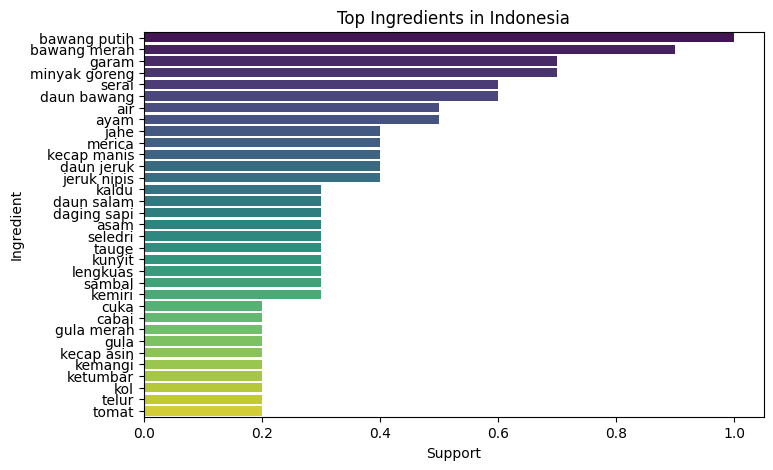

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

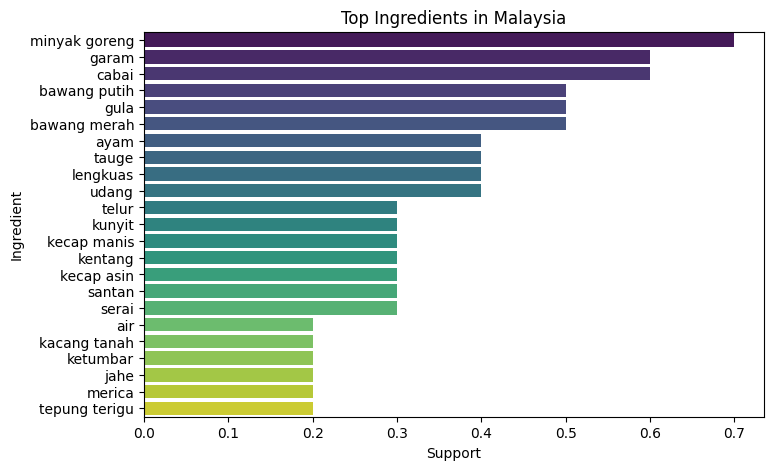

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

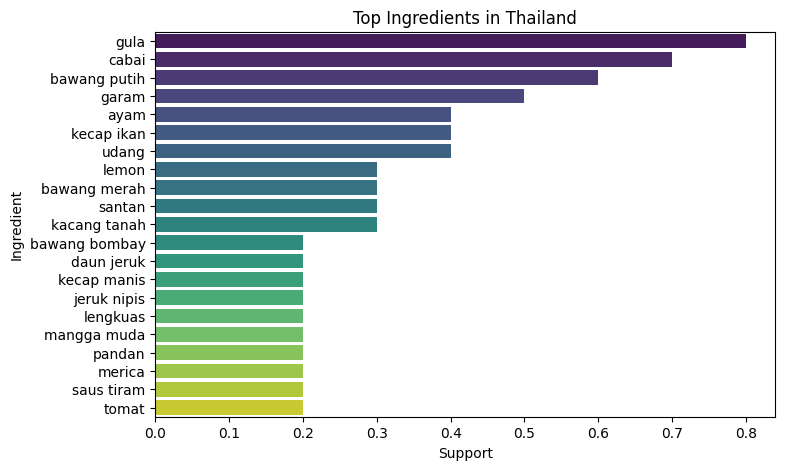

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

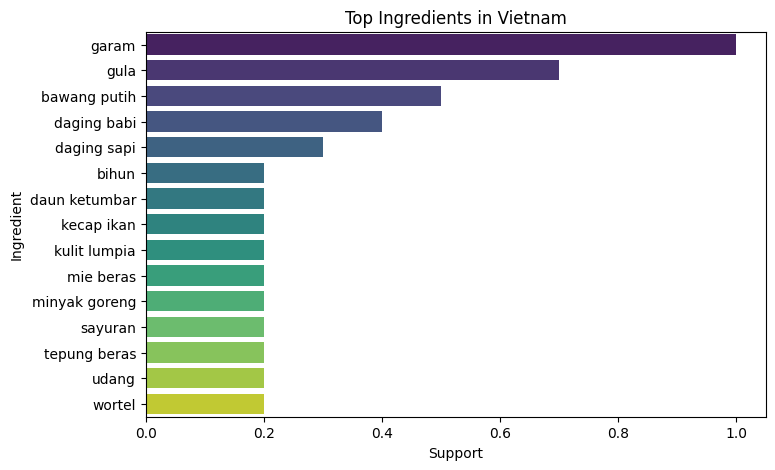

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

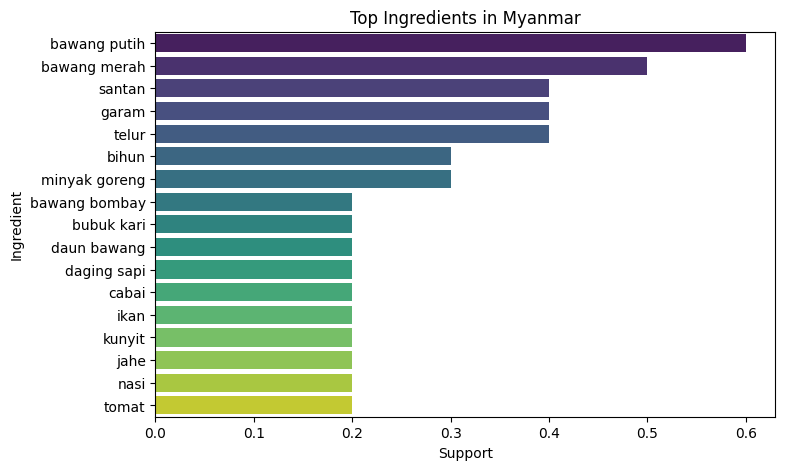

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

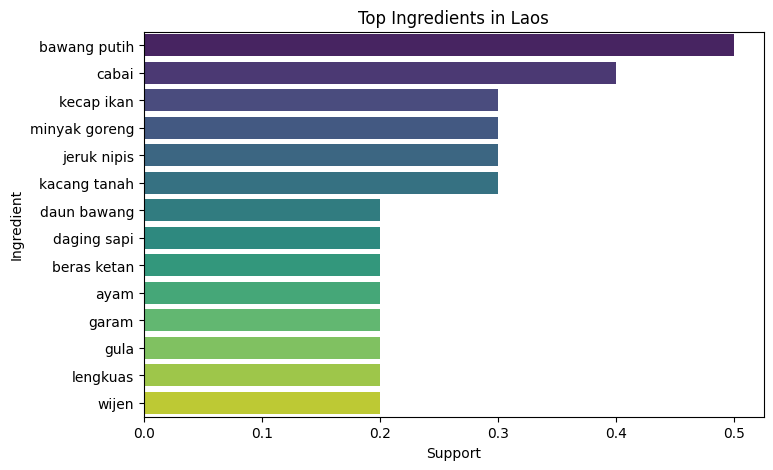

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

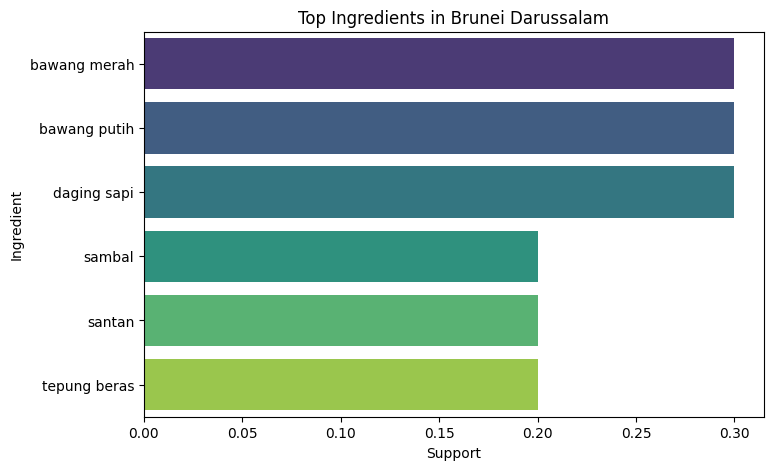

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

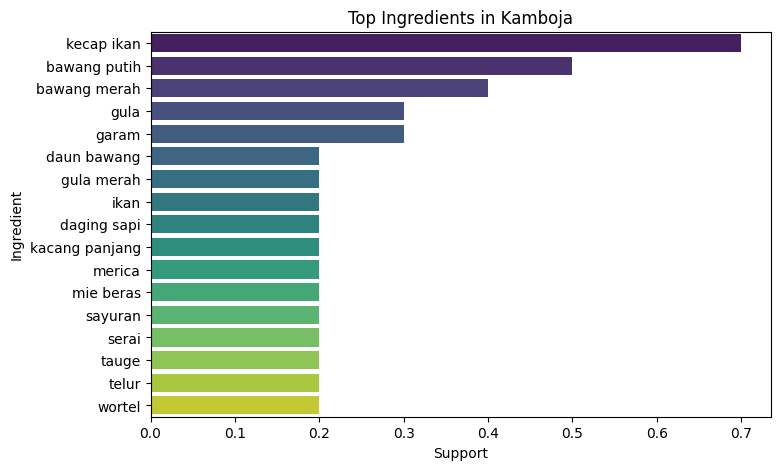

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

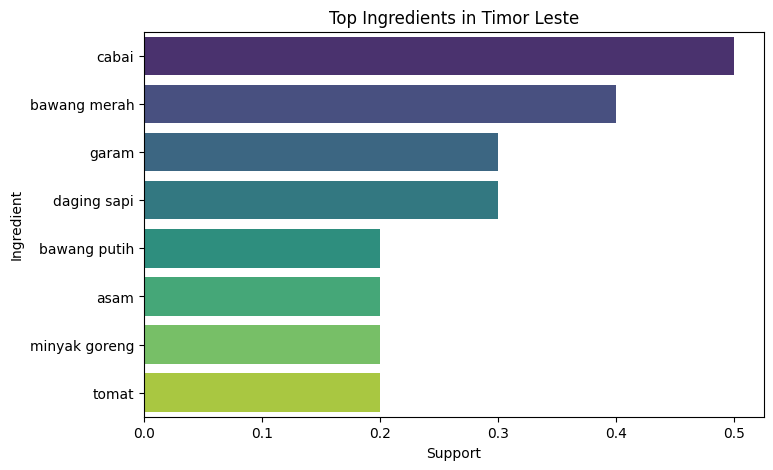

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

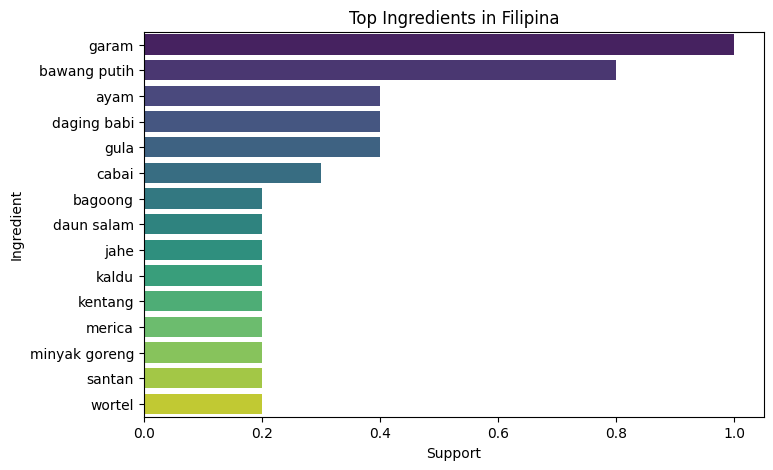

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

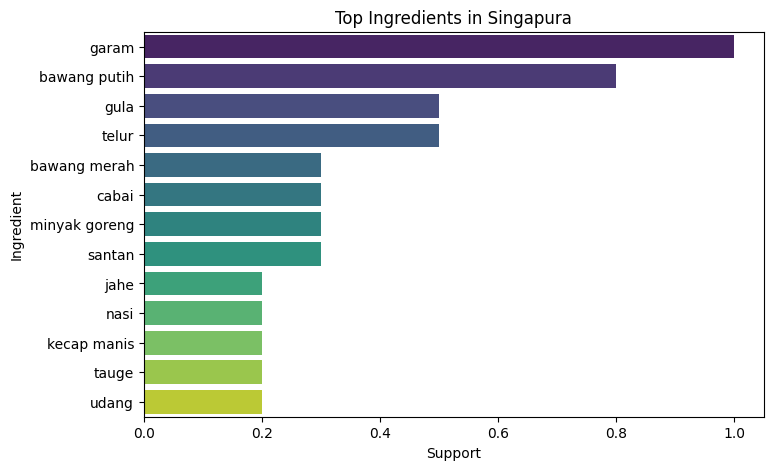

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

In [12]:
for country, frequent_itemsets in frequent_itemsets_per_country.items():
    if frequent_itemsets.empty:
        print(f"Tidak ada data untuk {country}")
        continue
    
    one_itemsets = frequent_itemsets[frequent_itemsets['itemset_length'] == 1]
    
    if one_itemsets.empty:
        print(f"Tidak ada 1-itemset untuk {country}")
        continue
    
    one_itemsets_plot = one_itemsets.copy()
    one_itemsets_plot['ingredient'] = one_itemsets_plot['itemsets'].apply(lambda x: list(x)[0])
    one_itemsets_plot = one_itemsets_plot.sort_values(by='support', ascending=False)
    
    plt.figure(figsize=(8,5))
    sns.barplot(x='support', y='ingredient', data=one_itemsets_plot, palette='viridis')
    plt.title(f"Top Ingredients in {country}")
    plt.xlabel("Support")
    plt.ylabel("Ingredient")
    plt.show()

## Support vs Confidence Scatter Plot

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

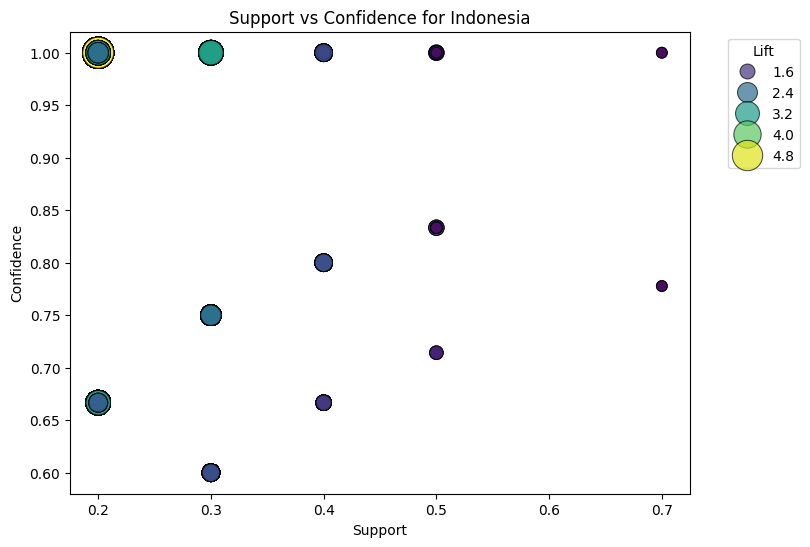

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

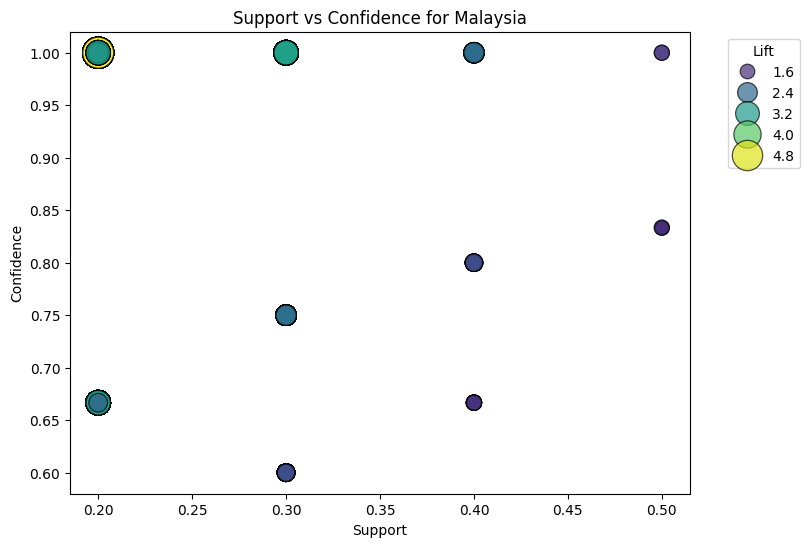

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

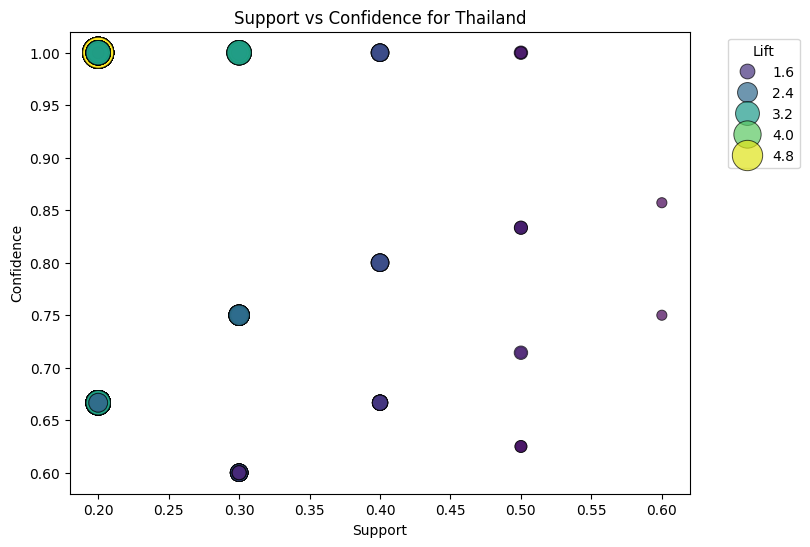

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

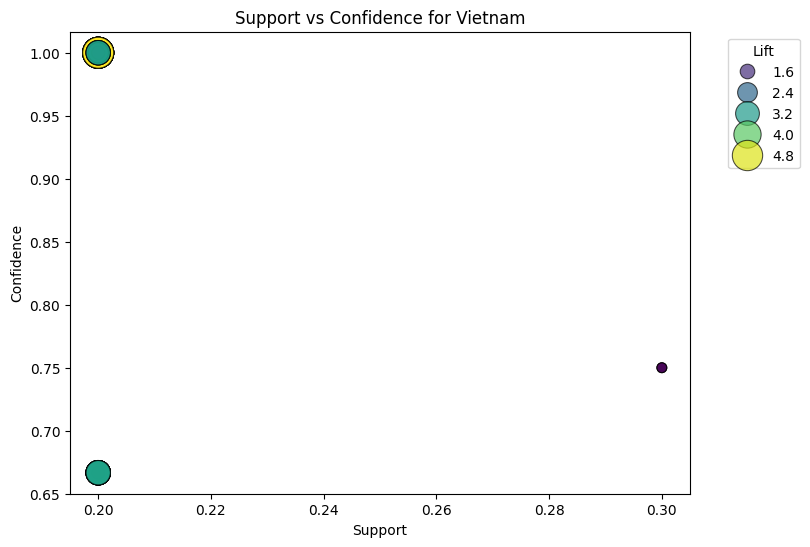

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

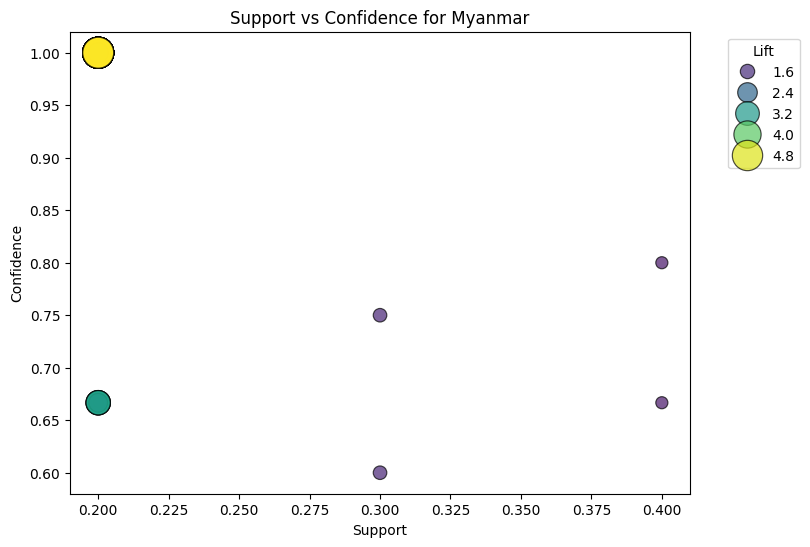

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

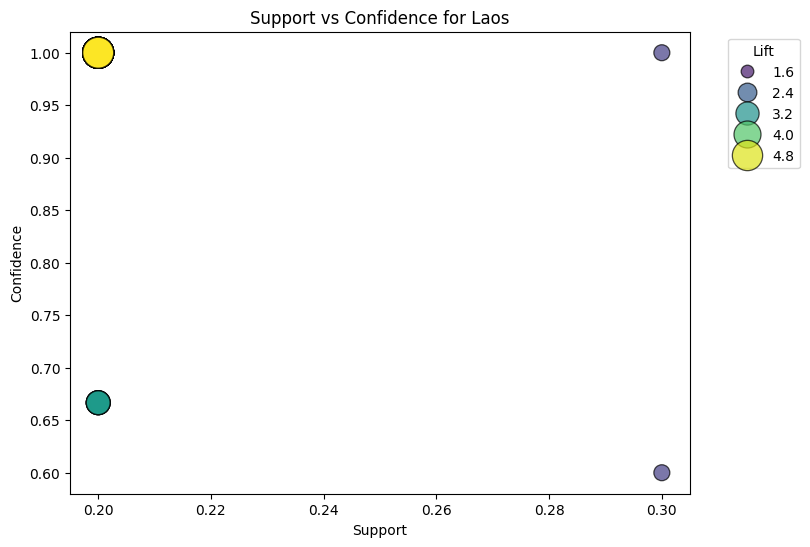

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

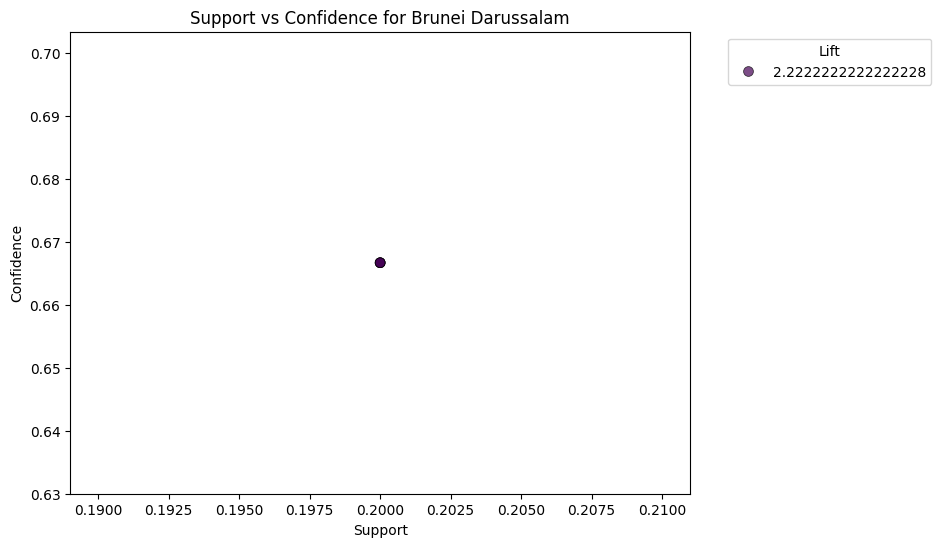

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

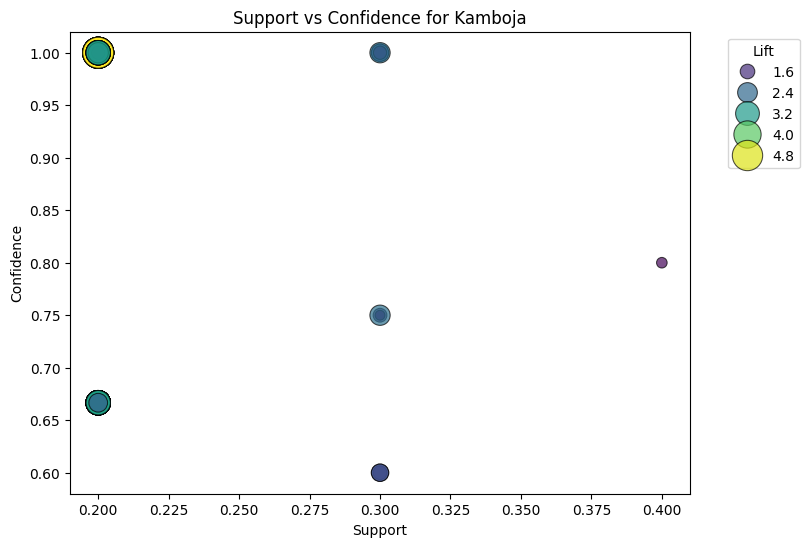

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

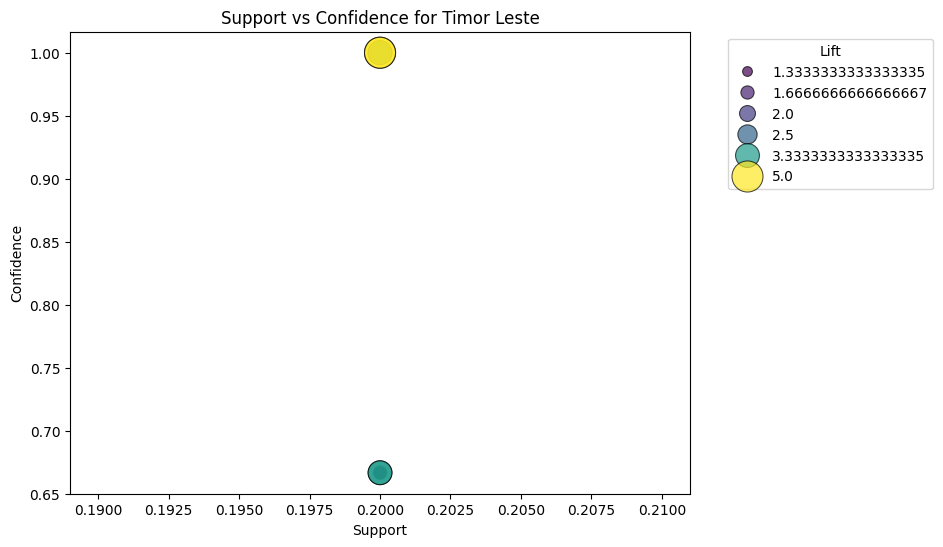

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

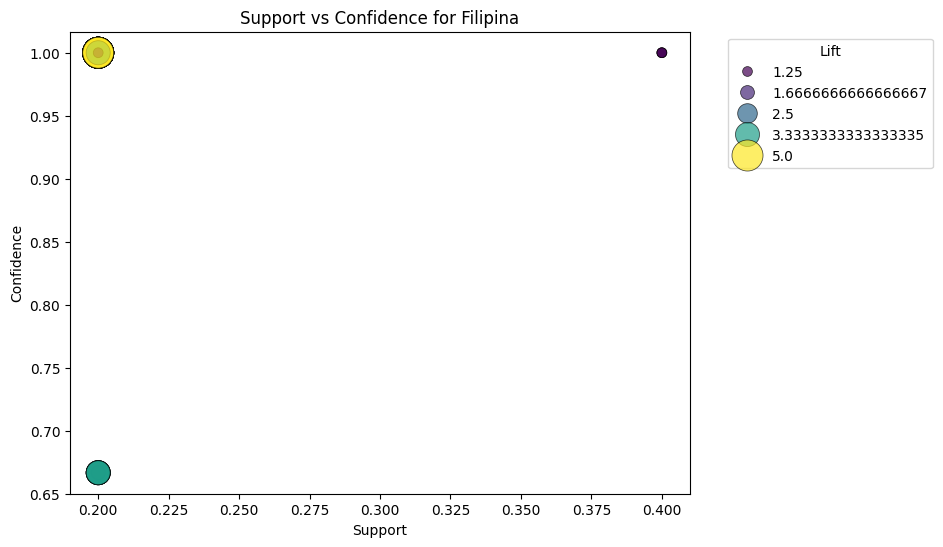

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

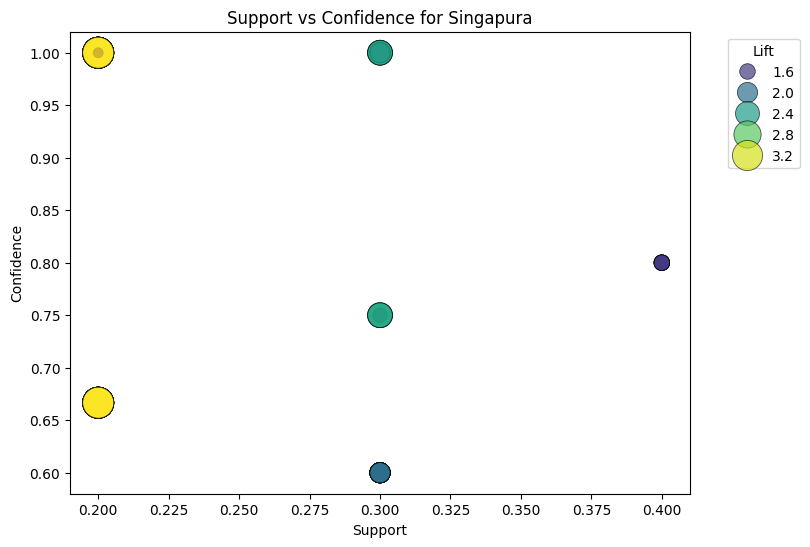

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

In [13]:
for country, rules in rules_per_country.items():
    if rules.empty:
        print(f"Tidak ada rules untuk {country}")
        continue
    
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=rules,
        x='support',
        y='confidence',
        size='lift',
        hue='lift',
        palette='viridis',
        sizes=(50, 500),
        alpha=0.7,
        edgecolor='k'
    )
    plt.title(f"Support vs Confidence for {country}")
    plt.xlabel("Support")
    plt.ylabel("Confidence")
    plt.legend(title='Lift', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

## Save Model

In [14]:
model = {
    'transactions_per_country': transactions_per_country,
    'encoded_per_country': encoded_per_country,
    'frequent_itemsets_per_country': frequent_itemsets_per_country,
    'rules_per_country': rules_per_country
}

with open('apriori_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Apriori model per country has been successfully saved to 'apriori_model.pkl'")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

Apriori model per country has been successfully saved to 'apriori_model.pkl'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

In [15]:
# Load the model for future use
with open('apriori_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

transactions_per_country = loaded_model['transactions_per_country']
encoded_per_country = loaded_model['encoded_per_country']
frequent_itemsets_per_country = loaded_model['frequent_itemsets_per_country']
rules_per_country = loaded_model['rules_per_country']

print("Model has been successfully loaded")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

Model has been successfully loaded


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

# Recommendation System Based on Association Rules

In [16]:
def smart_chef_per_country(country_input, user_ingredients_input, 
                           df=df, rules_per_country=rules_per_country):
    """
    Recommend recipes based on user ingredients for a specific country.
    Predict additional ingredients using association rules of that country.
    
    Parameters:
        country_input (str): Name of the country to filter recipes and rules
        user_ingredients_input (list of str): List of ingredients user has
        df (DataFrame): Full dataset of recipes
        rules_per_country (dict): Dictionary of association rules per country
        
    Returns:
        DataFrame: Recommended recipes sorted by match score
    """
    # Normalize input
    user_ingredients = set([b.strip().lower() for b in user_ingredients_input])
    
    # Get rules for the selected country
    rules = rules_per_country.get(country_input)
    if rules is None or rules.empty:
        print(f"No rules available for {country_input}. Returning basic ingredient match.")
        rules = pd.DataFrame(columns=['antecedents', 'consequents'])
    
    # Predict additional ingredients based on rules
    additional = set()
    for _, row in rules.iterrows():
        if row['antecedents'].issubset(user_ingredients):
            additional.update(row['consequents'])
    
    # Combine user ingredients with predicted ones
    total_ingredients = user_ingredients.union(additional)
    
    # Filter recipes by country
    df_country = df[df['negara'] == country_input]
    
    # Calculate match score
    results = []
    for _, row in df_country.iterrows():
        recipe_ingredients = set(row['ingredient_list'])
        match = recipe_ingredients.intersection(total_ingredients)
        score = len(match) / len(recipe_ingredients)
        
        if score > 0.2:  # Threshold 15%
            results.append({
                'Recipe': row['masakan'],
                'Country': row['negara'],
                'Match Score (%)': round(score * 100, 1),
                'Missing Ingredients': list(recipe_ingredients - total_ingredients)
            })
    
    return pd.DataFrame(results).sort_values('Match Score (%)', ascending=False)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

## TEST RUN

In [17]:
country_input = 'Malaysia'
user_input = ['bawang merah', 'garam', 'air']

recommendation = smart_chef_per_country(country_input, user_input)

print(f"\nYour Ingredients: {user_input} | Country: {country_input}")
print(f"\nRecomendation Recipe")
display(recommendation)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin


Your Ingredients: ['bawang merah', 'garam', 'air'] | Country: Malaysia

Recomendation Recipe


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

,Recipe,Country,Match Score (%),Missing Ingredients
4,Roti Canai,Malaysia,80.0,[tepung terigu]
1,Chicken Curry,Malaysia,64.7,"[kecap asin, cuka, bawang bombay, jahe, biji m..."
2,Gulai Ikan Asin,Malaysia,61.5,"[ikan asin, ketumbar, terasi, daun jeruk purut..."
0,Nasi Lemak,Malaysia,53.3,"[beras, kacang tanah, pandan, ikan teri, telur..."
6,Laksa Penang,Malaysia,52.6,"[seafood, kaldu, susu, jeruk nipis, jintan, ke..."
3,Miee Goreng Mualim,Malaysia,41.7,"[kecap asin, saus tomat, tauge, mie kuning, me..."
5,Char Kway Teow,Malaysia,33.3,"[kwetiau, kerang, tauge, udang, telur, kecap m..."


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin